Day 7 : Sustainable Climate Data Analysis Using K-Means Clustering

Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

Step 2: Upload Dataset

In [2]:
from google.colab import files
uploaded = files.upload()

Saving climate_change_dataset.csv to climate_change_dataset.csv


Step 3: Load Dataset

In [3]:

df = pd.read_csv("climate_change_dataset.csv")
df.head()

,Year,Country,Avg Temperature (°C),CO2 Emissions (Tons/Capita),Sea Level Rise (mm),Rainfall (mm),Population,Renewable Energy (%),Extreme Weather Events,Forest Area (%)
0,2006,UK,8.9,9.3,3.1,1441,530911230,20.4,14,59.8
1,2019,USA,31.0,4.8,4.2,2407,107364344,49.2,8,31.0
2,2014,France,33.9,2.8,2.2,1241,441101758,33.3,9,35.5
3,2010,Argentina,5.9,1.8,3.2,1892,1069669579,23.7,7,17.7
4,2007,Germany,26.9,5.6,2.4,1743,124079175,12.5,4,17.4


In [4]:
print("Rows and Columns:", df.shape)

Rows and Columns: (1000, 10)


Step 4: Analyze Dataset

In [5]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Year                         1000 non-null   int64  
 1   Country                      1000 non-null   object 
 2   Avg Temperature (°C)         1000 non-null   float64
 3   CO2 Emissions (Tons/Capita)  1000 non-null   float64
 4   Sea Level Rise (mm)          1000 non-null   float64
 5   Rainfall (mm)                1000 non-null   int64  
 6   Population                   1000 non-null   int64  
 7   Renewable Energy (%)         1000 non-null   float64
 8   Extreme Weather Events       1000 non-null   int64  
 9   Forest Area (%)              1000 non-null   float64
dtypes: float64(5), int64(4), object(1)
memory usage: 78.3+ KB


,0
Year,0
Country,0
Avg Temperature (°C),0
CO2 Emissions (Tons/Capita),0
Sea Level Rise (mm),0
Rainfall (mm),0
Population,0
Renewable Energy (%),0
Extreme Weather Events,0
Forest Area (%),0


Step 5: Handle Missing Values

In [17]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [18]:
df = df.fillna(df.mean(numeric_only=True))

Step 6: Select Numerical Columns

In [8]:
num_df = df.select_dtypes(include=np.number)
num_df.head()

,Year,Avg Temperature (°C),CO2 Emissions (Tons/Capita),Sea Level Rise (mm),Rainfall (mm),Population,Renewable Energy (%),Extreme Weather Events,Forest Area (%)
0,2006,8.9,9.3,3.1,1441,530911230,20.4,14,59.8
1,2019,31.0,4.8,4.2,2407,107364344,49.2,8,31.0
2,2014,33.9,2.8,2.2,1241,441101758,33.3,9,35.5
3,2010,5.9,1.8,3.2,1892,1069669579,23.7,7,17.7
4,2007,26.9,5.6,2.4,1743,124079175,12.5,4,17.4


Step 7: Scale the Data

In [9]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(num_df)

Step 8: Elbow Method

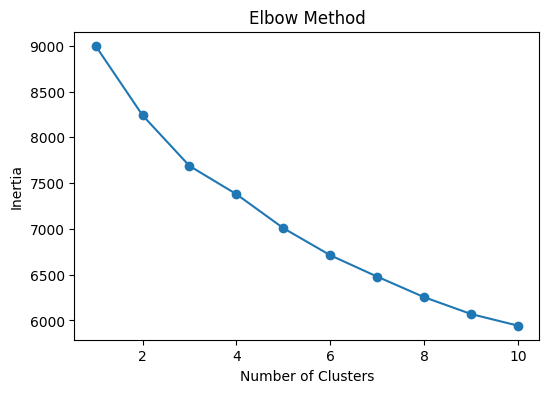

In [10]:
inertia = []

for i in range(1,11):
    km = KMeans(n_clusters=i, random_state=42)
    km.fit(scaled_data)
    inertia.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,11), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

Step 9: Apply K-Means  

  (Assume K = 3)

In [11]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

num_df["Cluster"] = clusters

## Cluster Analysis

In [19]:
print(num_df["Cluster"].value_counts())

cluster_summary = num_df.groupby("Cluster").mean()
cluster_summary

Cluster
0    350
1    344
2    306
Name: count, dtype: int64


,Year,Avg Temperature (°C),CO2 Emissions (Tons/Capita),Sea Level Rise (mm),Rainfall (mm),Population,Renewable Energy (%),Extreme Weather Events,Forest Area (%)
Cluster,,,,,,,,,
0,2017.771429,23.078571,10.488286,3.378857,1755.577143,8.257604e+08,29.156286,8.111429,36.146571
1,2010.119186,11.597093,10.634884,2.515116,1742.784884,7.411153e+08,29.324709,6.183140,43.060174
2,2005.656863,25.543137,10.119281,3.143137,1715.003268,5.275270e+08,22.902288,7.598039,42.836601


Step 10: Scatter Plot

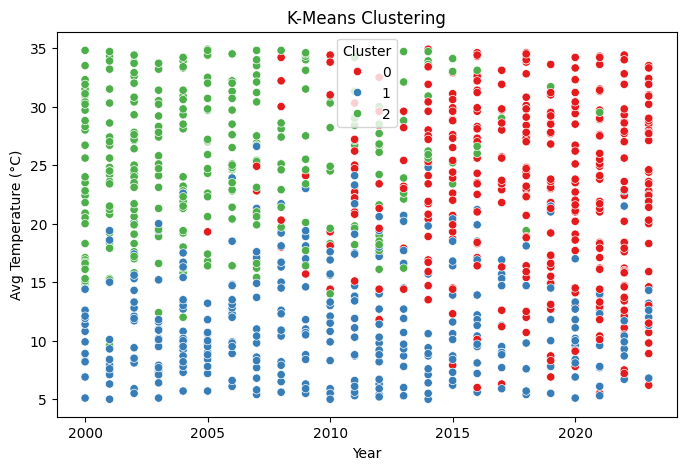

In [12]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=num_df.iloc[:,0],
    y=num_df.iloc[:,1],
    hue=num_df["Cluster"],
    palette="Set1"
)

plt.title("K-Means Clustering")
plt.show()

Step 11: Heatmap

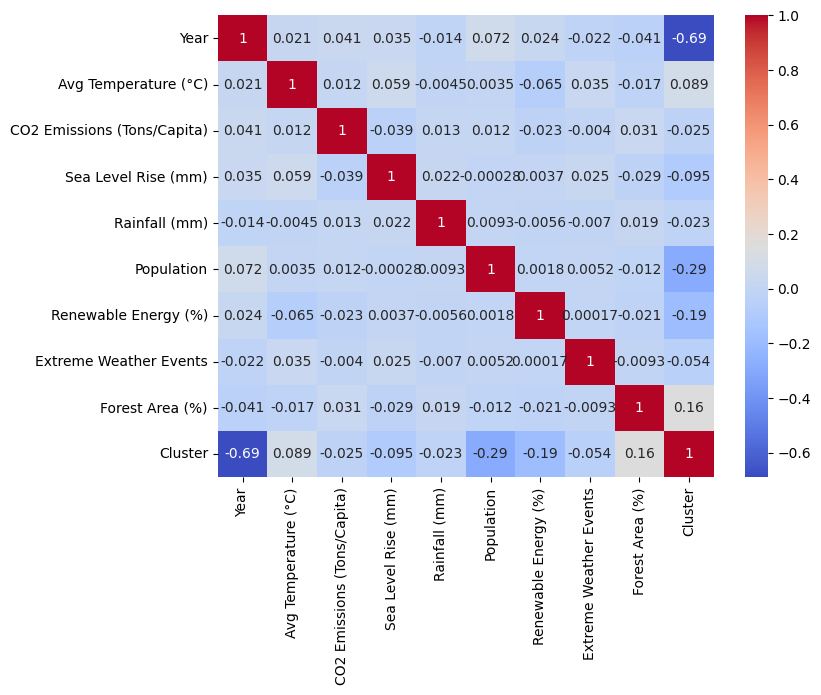

In [13]:
plt.figure(figsize=(8,6))
sns.heatmap(num_df.corr(), annot=True, cmap="coolwarm")
plt.show()

Step 12: Boxplot

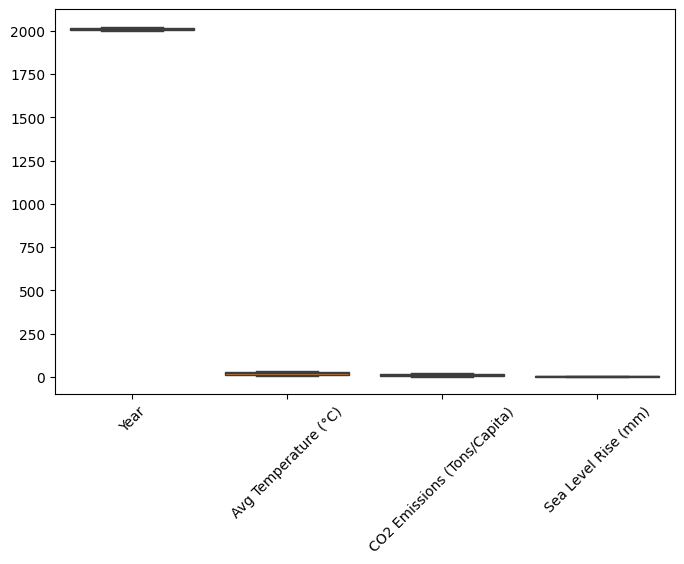

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(data=num_df.iloc[:,:4])
plt.xticks(rotation=45)
plt.show()

Step 13: Evaluation

In [15]:
score = silhouette_score(scaled_data, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.07895926636103202


Step 14: Final Output

In [16]:
num_df.head()

,Year,Avg Temperature (°C),CO2 Emissions (Tons/Capita),Sea Level Rise (mm),Rainfall (mm),Population,Renewable Energy (%),Extreme Weather Events,Forest Area (%),Cluster
0,2006,8.9,9.3,3.1,1441,530911230,20.4,14,59.8,1
1,2019,31.0,4.8,4.2,2407,107364344,49.2,8,31.0,0
2,2014,33.9,2.8,2.2,1241,441101758,33.3,9,35.5,2
3,2010,5.9,1.8,3.2,1892,1069669579,23.7,7,17.7,1
4,2007,26.9,5.6,2.4,1743,124079175,12.5,4,17.4,2


Conclusion:
The climate change dataset was cleaned and analyzed using Seaborn. Numerical features were scaled before applying the K-Means clustering algorithm. The Elbow Method was used to choose the number of clusters, and the Silhouette Score was used to evaluate clustering quality. The results grouped similar climate records into clusters, helping identify meaningful sustainability-related patterns.